In [3]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Input
from keras.utils import to_categorical
from matplotlib import pyplot as plt
import tensorflow as tf
import random

In [4]:
mnist_data = mnist.load_data()
(x_train, y_train), (x_test, y_test) = mnist_data
(x_train.shape, y_train.shape), (x_test.shape, y_test.shape)

(((60000, 28, 28), (60000,)), ((10000, 28, 28), (10000,)))

label: 9


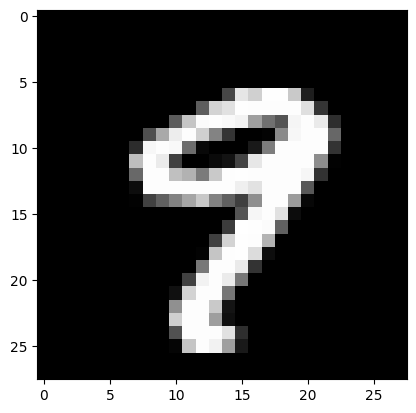

In [5]:
idx = random.randint(0, x_train.shape[0])
plt.imshow(x_train[idx], cmap='gray')
print(f'label: {y_train[idx]}')

In [6]:
y_train_labels = to_categorical(y_train, 10)
y_test_labels = to_categorical(y_test, 10)

In [7]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(filters=8, kernel_size=3, activation='relu'),
    MaxPool2D(pool_size=2, strides=2),
    Flatten(),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', 
              metrics=[
                  'accuracy',
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall'),
                    tf.keras.metrics.AUC(name='auc')
                  ])

In [8]:
model.fit(x_train, y_train_labels, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8963 - auc: 0.9681 - loss: 1.1705 - precision: 0.8980 - recall: 0.8954
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9576 - auc: 0.9954 - loss: 0.1579 - precision: 0.9605 - recall: 0.9560
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9688 - auc: 0.9975 - loss: 0.1063 - precision: 0.9714 - recall: 0.9669
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9731 - auc: 0.9983 - loss: 0.0885 - precision: 0.9751 - recall: 0.9713
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9758 - auc: 0.9983 - loss: 0.0789 - precision: 0.9776 - recall: 0.9747


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
label: 4


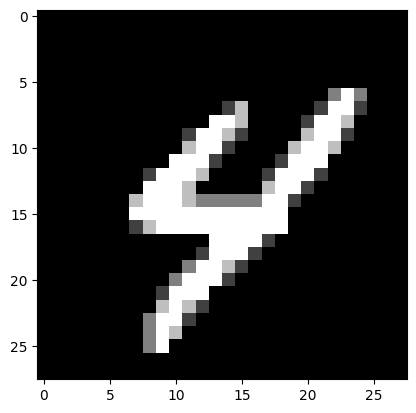

In [9]:
idx = random.randint(0, x_test.shape[0])
model.predict(x_test[idx:idx+1])
plt.imshow(x_test[idx], cmap='gray')
print(f'label: {y_test[idx]}')

In [10]:
loss, accuracy, precision, recall, f1_score = model.evaluate(x_test, y_test_labels)
print(f'\n\nloss: {loss},\naccuracy: {accuracy},\nprecision: {precision},\nrecall: {recall},\nf1_score: {f1_score}')
model.summary()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9682 - auc: 0.9959 - loss: 0.1271 - precision: 0.9698 - recall: 0.9671


loss: 0.12713566422462463,
accuracy: 0.9682000279426575,
precision: 0.9698154926300049,
recall: 0.9671000242233276,
f1_score: 0.9959424734115601


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,832 (159.50 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,222 (106.34 KB)

In [11]:
model.save('mnist_cnn_model.keras')